In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))




TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os

base_path = "/content/drive/MyDrive/Patato Disease"

for split in ["Train", "Valid", "Test"]:
    path = os.path.join(base_path, split)

    print("\n", split)
    print(os.listdir(path))


 Train
['Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight']

 Valid
['.DS_Store', 'Potato___healthy', 'Potato___Late_blight', 'Potato___Early_blight']

 Test
['Potato___Late_blight', 'Potato___healthy', 'Potato___Early_blight']


In [ ]:
import os

base_path = "/content/drive/MyDrive/Patato Disease"

for split in ["Train", "Valid", "Test"]:
    print(f"\n===== {split} =====")

    split_path = os.path.join(base_path, split)

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            print(f"{class_name}: {count}")


===== Train =====
Potato___Early_blight: 300
Potato___healthy: 300
Potato___Late_blight: 300

===== Valid =====
Potato___healthy: 100
Potato___Late_blight: 100
Potato___Early_blight: 100

===== Test =====
Potato___Late_blight: 100
Potato___healthy: 100
Potato___Early_blight: 100


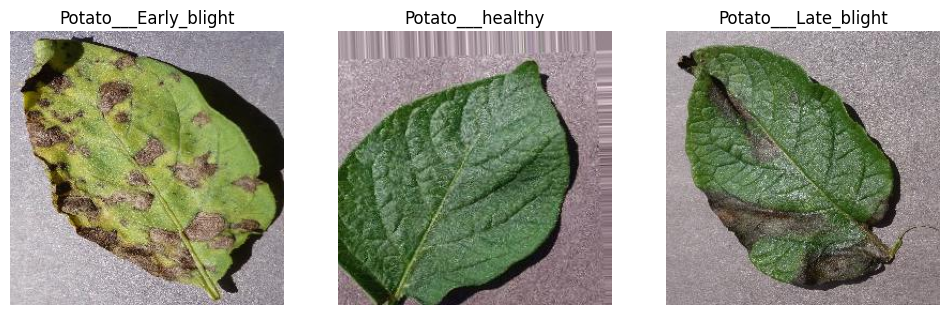

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image

base_path = "/content/drive/MyDrive/Patato Disease/Train"

classes = os.listdir(base_path)

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(base_path, class_name)

    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [ ]:
import tensorflow as tf

base_path = "/content/drive/MyDrive/Patato Disease"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    f"{base_path}/Train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_data = tf.keras.utils.image_dataset_from_directory(
    f"{base_path}/Valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    f"{base_path}/Test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 900 files belonging to 3 classes.
Found 300 files belonging to 3 classes.
Found 300 files belonging to 3 classes.


In [ ]:
print("Classes:", train_data.class_names)

Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [ ]:
images, labels = next(iter(train_data))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10].numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
First 10 labels: [1 1 2 0 1 2 2 0 1 2]


In [ ]:
print("Data type:", images.dtype)

print("\nOne pixel:")
print(images[0, 0, 0])

print("\nFirst 5 x 5 pixels:")
print(images[0, :5, :5])

Data type: <dtype: 'float32'>

One pixel:
tf.Tensor([167.29082 158.29082 161.29082], shape=(3,), dtype=float32)

First 5 x 5 pixels:
tf.Tensor(
[[[167.29082  158.29082  161.29082 ]
  [165.39796  156.39796  159.39796 ]
  [149.53061  140.53061  143.53061 ]
  [164.25     155.25     158.25    ]
  [164.22958  155.22958  158.22958 ]]

 [[167.94896  158.94896  161.94896 ]
  [185.7704   176.7704   179.7704  ]
  [171.55103  162.55103  165.55103 ]
  [154.71428  145.71428  148.71428 ]
  [155.64796  146.64796  149.64796 ]]

 [[128.47449  119.474495 122.474495]
  [155.97449  146.97449  149.97449 ]
  [153.89285  144.89285  147.89285 ]
  [156.03572  147.03572  150.03572 ]
  [171.77042  162.77042  165.77042 ]]

 [[142.5      133.5      136.5     ]
  [173.7143   164.7143   167.7143  ]
  [156.5      147.5      150.5     ]
  [147.25     138.25     141.25    ]
  [163.39285  154.39285  157.39285 ]]

 [[150.7398   141.7398   144.7398  ]
  [176.20918  167.20918  170.20918 ]
  [162.09183  153.09183  156.09183

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

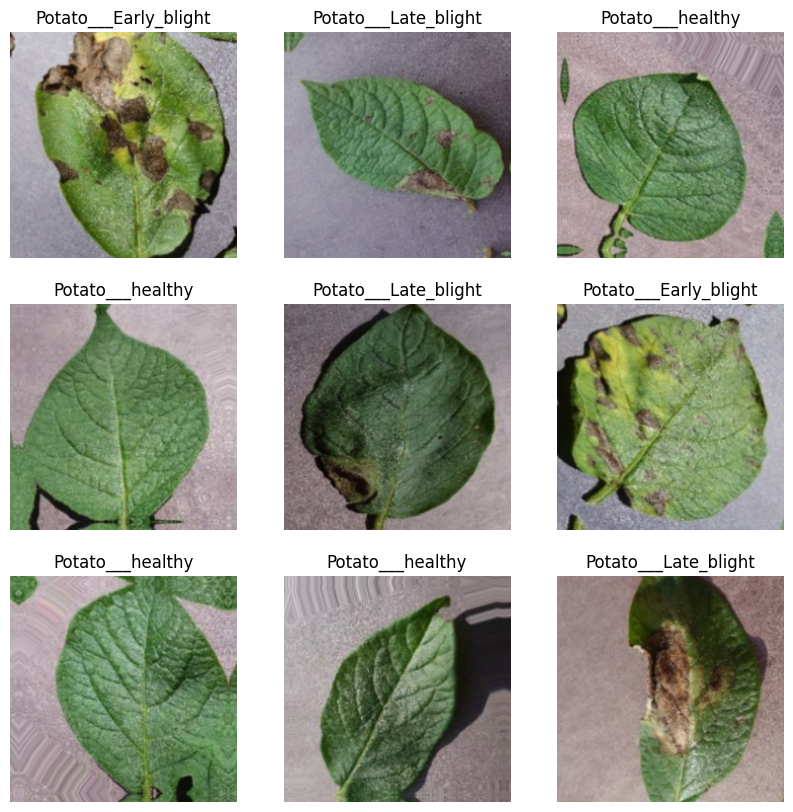

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):

    for i in range(9):

        augmented_image = data_augmentation(images[i])

        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image.numpy().astype("uint8"))
        plt.title(train_data.class_names[labels[i]])
        plt.axis("off")

plt.show()

In [ ]:
!pip install -q tensorflow-hub

In [ ]:
import tensorflow_hub as hub
import tensorflow as tf

MODEL_URL = "https://tfhub.dev/tensorflow/efficientnet/b0/feature-vector/1"

feature_extractor = hub.KerasLayer(
    MODEL_URL,
    input_shape=(224, 224, 3),
    trainable=False
)

/usr/local/lib/python3.13/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [ ]:
feature_extractor = hub.KerasLayer(
    MODEL_URL,
    input_shape=(224, 224, 3),
    trainable=False
)

In [ ]:
images, labels = next(iter(train_data))

features = feature_extractor(images[:1])

print("Feature shape:", features.shape)

Feature shape: (1, 1280)


In [ ]:
images, labels = next(iter(train_data))

images = images / 255.0

features = feature_extractor(images[:1])

print("Input shape:", images[:1].shape)
print("Feature shape:", features.shape)

Input shape: (1, 224, 224, 3)
Feature shape: (1, 1280)


In [ ]:
def extract_features(dataset):
    all_features = []
    all_labels = []

    for images, labels in dataset:
        images = images / 255.0

        features = feature_extractor(images)

        all_features.append(features.numpy())
        all_labels.append(labels.numpy())

    return np.concatenate(all_features), np.concatenate(all_labels)

In [ ]:
import numpy as np

X_train_features, y_train = extract_features(train_data)

print("Feature shape:", X_train_features.shape)
print("Label shape:", y_train.shape)

Feature shape: (900, 1280)
Label shape: (900,)


In [ ]:
X_valid_features, y_valid = extract_features(valid_data)

X_test_features, y_test = extract_features(test_data)

print("Validation feature shape:", X_valid_features.shape)
print("Validation label shape:", y_valid.shape)

print("Test feature shape:", X_test_features.shape)
print("Test label shape:", y_test.shape)

Validation feature shape: (300, 1280)
Validation label shape: (300,)
Test feature shape: (300, 1280)
Test label shape: (300,)


In [ ]:
classifier = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1280,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation="softmax")
])

classifier.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,843 (15.01 KB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = classifier.fit(
    X_train_features,
    y_train,
    validation_data=(X_valid_features, y_valid),
    epochs=20,
    batch_size=32
)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.7878 - loss: 0.6211 - val_accuracy: 0.9367 - val_loss: 0.3193
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9600 - loss: 0.2426 - val_accuracy: 0.9667 - val_loss: 0.1985
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9711 - loss: 0.1694 - val_accuracy: 0.9567 - val_loss: 0.1635
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9856 - loss: 0.1248 - val_accuracy: 0.9833 - val_loss: 0.1230
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9933 - loss: 0.0996 - val_accuracy: 0.9867 - val_loss: 0.1072
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9889 - loss: 0.0874 - val_accuracy: 0.9867 - val_loss: 0.0932
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9900 - loss: 0.0775 - val_accuracy: 0.9867 - val_loss: 0.0793
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9900 - loss: 0.0692 - val_accuracy: 0.9900 - val_loss

In [ ]:
test_loss, test_accuracy = classifier.evaluate(
    X_test_features,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9967 - loss: 0.0279 
Test Loss: 0.02786671556532383
Test Accuracy: 0.996666669845581


In [ ]:
y_pred_probs = classifier.predict(X_test_features)

y_pred = np.argmax(y_pred_probs, axis=1)

print("First 20 actual labels:")
print(y_test[:20])

print("\nFirst 20 predicted labels:")
print(y_pred[:20])

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
First 20 actual labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First 20 predicted labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=train_data.class_names
))

                       precision    recall  f1-score   support

Potato___Early_blight       0.99      1.00      1.00       100
 Potato___Late_blight       1.00      0.99      0.99       100
     Potato___healthy       1.00      1.00      1.00       100

             accuracy                           1.00       300
            macro avg       1.00      1.00      1.00       300
         weighted avg       1.00      1.00      1.00       300



In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[100   0   0]
 [  1  99   0]
 [  0   0 100]]


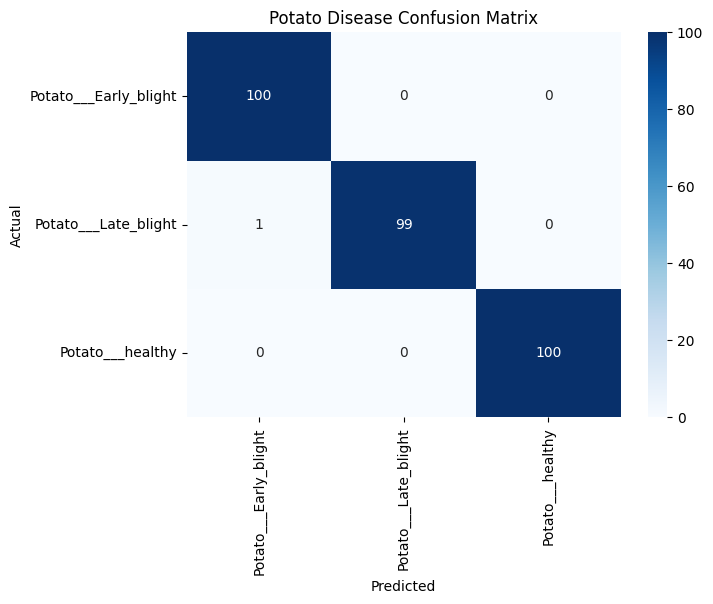

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.class_names,
    yticklabels=train_data.class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Potato Disease Confusion Matrix")
plt.show()

In [ ]:
classifier.save(
    "/content/drive/MyDrive/Patato Disease/potato_classifier.keras"
)

In [ ]:
import os

model_path = "/content/drive/MyDrive/Patato Disease/potato_classifier.keras"

print("Model saved:", os.path.exists(model_path))

Model saved: True


In [ ]:
import tensorflow as tf
import numpy as np

class_names = train_data.class_names

def predict_disease(image_path):

    # Load image
    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    # Convert image to array
    image = tf.keras.utils.img_to_array(image)

    # Add batch dimension
    image = np.expand_dims(image, axis=0)

    # Scale pixels from 0-255 to 0-1
    image = image / 255.0

    # Extract EfficientNet features
    features = feature_extractor(image)

    # Classifier prediction
    probabilities = classifier.predict(features, verbose=0)

    # Get highest probability
    predicted_class = np.argmax(probabilities[0])
    confidence = probabilities[0][predicted_class]

    print("Prediction:", class_names[predicted_class])
    print("Confidence:", round(float(confidence) * 100, 2), "%")

In [ ]:
import glob

test_images = glob.glob(
    "/content/drive/MyDrive/Patato Disease/Test/*/*.JPG"
)

print("Number of images:", len(test_images))
print("First image:", test_images[0])

Number of images: 200
First image: /content/drive/MyDrive/Patato Disease/Test/Potato___Late_blight/44722935-fb60-4ecf-8503-f8258aa4e3e7___RS_LB 3225.JPG


In [ ]:
predict_disease(test_images[0])

Prediction: Potato___Late_blight
Confidence: 99.84 %


In [ ]:
@tf.function(
    input_signature=[
        tf.TensorSpec(shape=[None, 224, 224, 3], dtype=tf.float32)
    ]
)
def serving_model(images):

    # EfficientNet feature extraction
    features = feature_extractor(images / 255.0)

    # Classification
    probabilities = classifier(features)

    return probabilities

In [ ]:
test_batch = tf.convert_to_tensor(
    images[:2],
    dtype=tf.float32
)

predictions = serving_model(test_batch)

print("Prediction shape:", predictions.shape)
print(predictions)

Prediction shape: (2, 3)
tf.Tensor(
[[0.3465388  0.44636565 0.2070955 ]
 [0.34661052 0.44605216 0.20733733]], shape=(2, 3), dtype=float32)


In [ ]:
images_test, labels_test = next(iter(test_data))

predictions = serving_model(
    tf.cast(images_test[:2], tf.float32)
)

print("Prediction shape:", predictions.shape)
print(predictions)

Prediction shape: (2, 3)
tf.Tensor(
[[9.9954993e-01 4.3381919e-04 1.6251975e-05]
 [9.9992383e-01 4.5073444e-05 3.1073887e-05]], shape=(2, 3), dtype=float32)


In [ ]:
class PotatoDiseaseModel(tf.Module):

    def __init__(self, feature_extractor, classifier):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.classifier = classifier

    @tf.function(
        input_signature=[
            tf.TensorSpec(
                shape=[None, 224, 224, 3],
                dtype=tf.float32
            )
        ]
    )
    def predict(self, images):

        # Convert 0-255 → 0-1
        images = images / 255.0

        # EfficientNet features
        features = self.feature_extractor(images)

        # Disease prediction
        probabilities = self.classifier(features)

        return probabilities


potato_model = PotatoDiseaseModel(
    feature_extractor,
    classifier
)

In [ ]:
save_path = "/content/drive/MyDrive/Patato Disease/potato_disease_model"

tf.saved_model.save(
    potato_model,
    save_path,
    signatures={
        "serving_default": potato_model.predict
    }
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
loaded_model = tf.saved_model.load(
    "/content/drive/MyDrive/Patato Disease/potato_disease_model"
)

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
predictions = loaded_model.predict(
    tf.cast(images_test[:1], tf.float32)
)

print("Prediction shape:", predictions.shape)
print("Prediction:", predictions.numpy())

Prediction shape: (1, 3)
Prediction: [[9.9954993e-01 4.3381919e-04 1.6252021e-05]]


In [ ]:
predicted_class = np.argmax(predictions.numpy()[0])
confidence = predictions.numpy()[0][predicted_class]

print("Prediction:", class_names[predicted_class])
print("Confidence:", round(float(confidence) * 100, 2), "%")

Prediction: Potato___Early_blight
Confidence: 99.95 %


In [ ]:
import shutil

source = "/content/drive/MyDrive/Patato Disease/potato_disease_model"
output = "/content/potato_disease_model"

shutil.make_archive(
    output,
    "zip",
    source
)

print("ZIP created successfully!")

ZIP created successfully!


In [ ]:
from google.colab import files

files.download("/content/potato_disease_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>